# Random Forest Classifier 

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [13]:
def generate_multiclass_data(n_samples=300):
    X = np.random.randn(n_samples, 5)
    y = np.zeros(n_samples, dtype=int)

    y[X[:, 0]**2 + X[:, 1]**2 > 2] = 1
    y[X[:, 2] + X[:, 3] > 1] = 2
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_multiclass_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,0.337377,0.001605,-1.844968,1.408126,0.554598,0
1,-0.048886,0.339806,-0.700711,0.581727,-0.164340,0
2,-1.756400,1.310567,2.532182,-1.602307,0.007262,1
3,0.990061,-0.245152,-0.950716,-0.584699,0.268625,0
4,1.380997,0.510365,-1.650273,0.606042,0.234836,1


## 2. Decision Tree Classifier (Dependency)

In [14]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        labels = np.unique(y)
        if depth >= self.max_depth or n_samples < self.min_samples_split or len(labels) == 1:
            return Node(value=np.bincount(y).argmax())
        
        # Key for RF: subsets of features
        features = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)
        best_feat, best_thresh = self._best_split(X, y, features)
        
        if best_feat is None:
            return Node(value=np.bincount(y).argmax())
        
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, features):
        best_gini = 1.0
        split_idx, split_thresh = None, None
        for feat_idx in features:
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                left_y = y[X[:, feat_idx] <= thresh]
                right_y = y[X[:, feat_idx] > thresh]
                if len(left_y) > 0 and len(right_y) > 0:
                    gini = self._calculate_gini(left_y, right_y)
                    if gini < best_gini:
                        best_gini = gini
                        split_idx = feat_idx
                        split_thresh = thresh
        return split_idx, split_thresh

    def _calculate_gini(self, left_y, right_y):
        def gini(sub_y):
            probs = np.bincount(sub_y) / len(sub_y)
            return 1 - np.sum(probs**2)
        n = len(left_y) + len(right_y)
        return (len(left_y)/n)*gini(left_y) + (len(right_y)/n)*gini(right_y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None: return node.value
        if x[node.feature] <= node.threshold: return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Implementation

In [ ]:
from collections import Counter

class RandomForestClassifier:
    def __init__(self, n_trees=10, max_depth=5, min_samples_split=2, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = [] 

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape

        if self.max_features is None:
            self.max_features = int(np.sqrt(n_features))

        for _ in range(self.n_trees):
            sample_indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]

            feature_indices = np.random.choice(
                n_features,
                self.max_features,
                replace=False
            )

            X_sample_subset = X_sample[:, feature_indices]

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_sample_subset, y_sample)

            self.trees.append((tree, feature_indices))

    def predict(self, X):
        tree_preds = []

        for tree, feature_indices in self.trees:
            preds = tree.predict(X[:, feature_indices])
            tree_preds.append(preds)

        tree_preds = np.array(tree_preds)

        final_preds = []
        for i in range(X.shape[0]):
            votes = Counter(tree_preds[:, i])
            final_preds.append(votes.most_common(1)[0][0])

        return np.array(final_preds)

## 4. Training and Visualization

Accuracy: 97.00%


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10728\1176140686.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette='viridis')


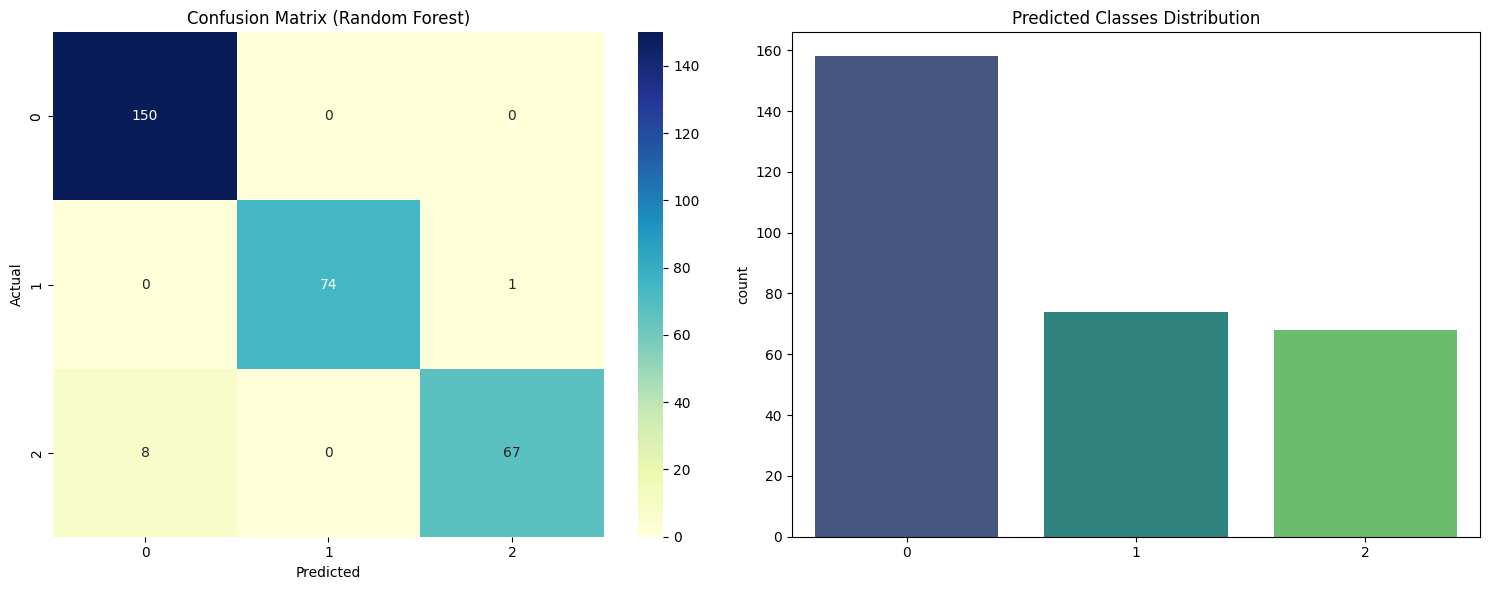

In [16]:
model = RandomForestClassifier(n_trees=15, max_depth=10)
model.fit(X, y)

y_pred = model.predict(X)
print(f"Accuracy: {np.mean(y == y_pred) * 100:.2f}%")

plt.figure(figsize=(15, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
matrix = pd.crosstab(results_df['Actual'], results_df['Predicted'])
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix (Random Forest)")

# 2. Prediction counts
plt.subplot(1, 2, 2)
sns.countplot(x=y_pred, palette='viridis')
plt.title("Predicted Classes Distribution")

plt.tight_layout()
plt.show()